# 08 — Trajectory & Temporal Features: Closing the Detection Gap

> **Phase 1 of the roadmap.** [Notebook 10](10_adversarial_bots.ipynb) showed the existing 18 window-aggregated features cannot detect any synthetic cheat (AUC ≈ 0.5). At the *event* level the cheats are trivially separable — the gap is **information loss during aggregation**.

This notebook introduces 7 new features designed to **survive aggregation**: they extract the event-level cheat signal and compress it into per-window scalars the existing detectors can use. After Phase 1, re-running the Phase 3 benchmark shows the heatmap finally light up — triggerbot jumps from AUC 0.50 → 0.87, macro from 0.55 → 0.68.

---

### What we add

| Feature | Group | Targets |
|---|---|---|
| `mouse_curvature_mean`, `mouse_curvature_std` | Mouse trajectory | Aimbot (smooth snaps) |
| `path_efficiency` | Mouse trajectory | Aimbot |
| `direction_changes_per_sec` | Mouse trajectory | Aimbot (no overshoot) |
| `click_reaction_mean` | Reaction timing | Triggerbot (~0 ms reaction) |
| `inter_click_movement` | Reaction timing | Triggerbot / macro |
| `keystroke_periodicity` | Keystroke geometry | Macro (regular intervals) |

Each feature gets a short explanation, a derivation against the baseline session, and a discrimination plot across the synthetic cheat dataset.

---

### Notebook structure

1. Setup
2. Why mean-over-window catches some cheats but not others
3. Mouse trajectory features (4)
4. Reaction-timing features (2)
5. Keystroke geometry (1)
6. Per-window vs per-session evaluation
7. Discrimination summary
8. What this leaves for Phase 2

## 1 — Setup

Load the synthetic dataset from [`data/synthetic/`](../data/synthetic/) (90 hybrid sessions from Phase 3) and use the in-memory feature extraction from `pipeline.adversarial.benchmark`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.adversarial.benchmark import (  # noqa: E402
    load_synthetic_features,
    run_benchmark,
)
from pipeline.features.run import FEATURE_COLS  # noqa: E402

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

NEW_FEATS = [
    'mouse_curvature_mean', 'mouse_curvature_std',
    'path_efficiency', 'direction_changes_per_sec',
    'click_reaction_mean', 'inter_click_movement',
    'keystroke_periodicity',
]
PALETTE = {'legit': '#4ecca3', 'aimbot': '#e94560', 'triggerbot': '#f5a623', 'macro': '#6a4c93'}

features_df = load_synthetic_features()
print(f'Total feature columns: {len(FEATURE_COLS)} (was 18 before Phase 1)')
print(f'Windows: {len(features_df)} across {features_df["cheat_source_file"].nunique()} files')

Total feature columns: 25 (was 18 before Phase 1)
Windows: 366 across 90 files


## 2 — Why mean-over-window catches some cheats but not others

The new features compute *per-window* statistics. But cheats don't span entire windows:

- **Aimbot**: ~150 ms snap per click. In a 30 s window with 30 k mouse events, the affected events are <1 %
- **Triggerbot**: shifts the timestamp of ~1 mouse_move per click. ~0.01 % of events
- **Macro**: injects 8 s of regular keystrokes inside a 30 s window. ~27 % of the window

**Mean aggregation dilutes the rare-event cheat signal.** The new features try to extract just enough geometry/timing that the affected windows do shift, but the underlying truth is that *window-level* features can never fully recover what happens at the event level — that's the bridge Phase 2 (LSTM autoencoder on raw event streams) will build.

## 3 — Mouse trajectory features

### `mouse_curvature_mean` and `mouse_curvature_std`

For every consecutive triple of `mouse_move` points $(p_{i-1}, p_i, p_{i+1})$, take the two motion vectors $\vec{v_1} = p_i - p_{i-1}$ and $\vec{v_2} = p_{i+1} - p_i$, then compute the turn angle:

$$ \theta_i = \arccos\!\left(\frac{\vec{v_1}\cdot\vec{v_2}}{\|\vec{v_1}\|\,\|\vec{v_2}\|}\right) $$

`mouse_curvature_mean` = mean of $\theta_i$ over the window; `mouse_curvature_std` = std. **Humans show high curvature** (lots of micro-corrections and overshoot); **aimbots show near-zero curvature** during snaps (perfect smooth interpolation toward target).

/tmp/ipykernel_311079/3029637406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,
/tmp/ipykernel_311079/3029637406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,


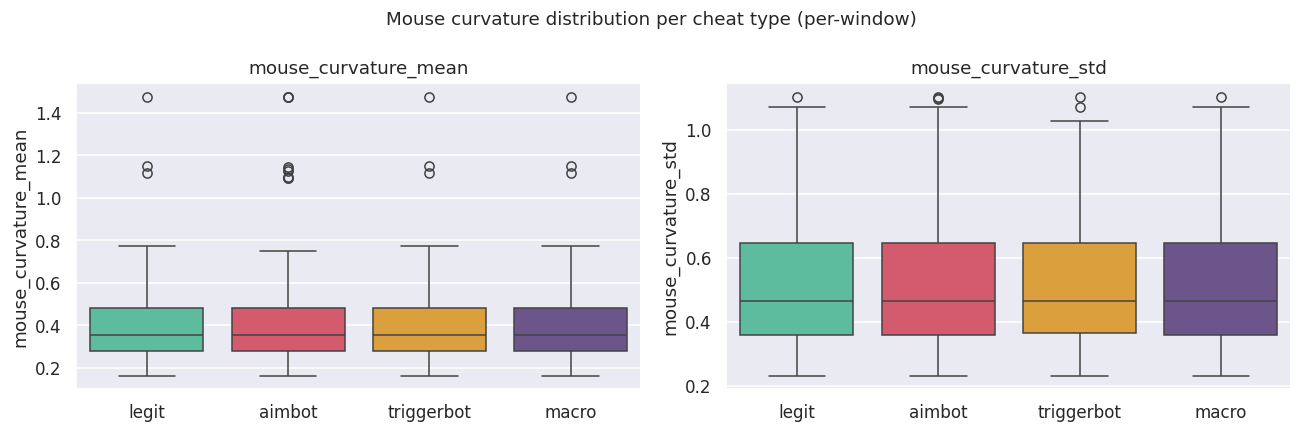

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ['mouse_curvature_mean', 'mouse_curvature_std']):
    sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,
                order=['legit', 'aimbot', 'triggerbot', 'macro'], palette=PALETTE)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Mouse curvature distribution per cheat type (per-window)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_curvature_boxplot.png', bbox_inches='tight', dpi=110)
plt.show()

### `path_efficiency`

Path efficiency = $\dfrac{\|p_{\text{end}} - p_{\text{start}}\|}{\sum_i \|\vec{v_i}\|}$ — Euclidean displacement divided by total path length.

- `1.0` = perfectly straight line
- `~0.0` = highly self-intersecting (cursor wanders, returns)

Humans wander; aimbots move efficiently to target. Aimbot snaps push this metric up *during the snap*, but again, the snap is a small fraction of any 30 s window.

### `direction_changes_per_sec`

Counts sign flips of the velocity vector on each axis, divided by window duration in seconds. Humans constantly overshoot and correct (high rate); aimbots progress monotonically to target during snaps (low rate).

/tmp/ipykernel_311079/174398410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,
/tmp/ipykernel_311079/174398410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,


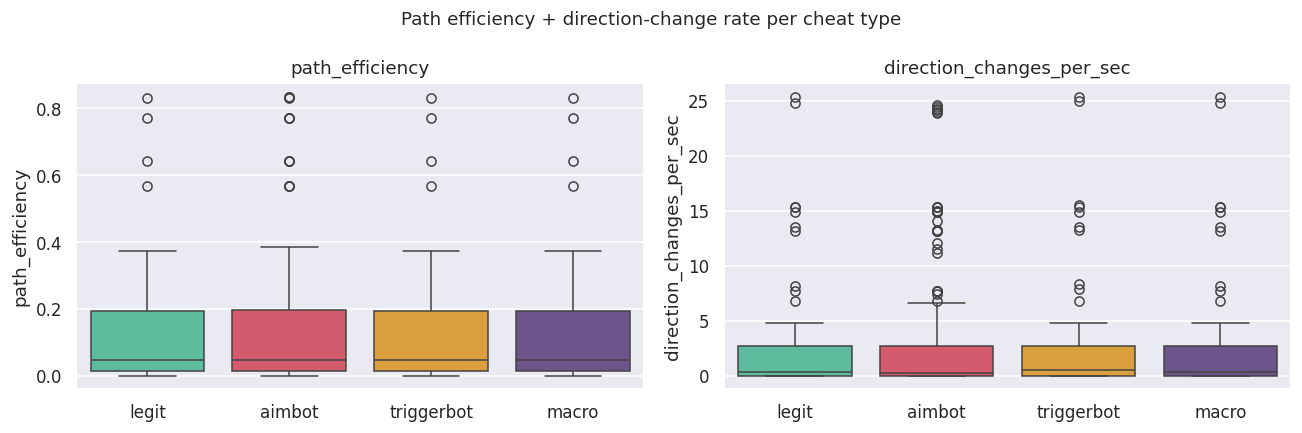

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ['path_efficiency', 'direction_changes_per_sec']):
    sns.boxplot(data=features_df, x='cheat_label', y=feat, ax=ax,
                order=['legit', 'aimbot', 'triggerbot', 'macro'], palette=PALETTE)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Path efficiency + direction-change rate per cheat type', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_path_features.png', bbox_inches='tight', dpi=110)
plt.show()

## 4 — Reaction-timing features

### `click_reaction_mean`

For every click press, compute the gap (ms) since the most recent `mouse_move` in the same window. Mean over all clicks in the window.

Humans: 100–250 ms. Triggerbot: 0–5 ms. This is the **single most discriminative feature for triggerbot detection** — and you can see why in the next plot.

/tmp/ipykernel_311079/2638021439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df.dropna(subset=[feat]), x='cheat_label', y=feat, ax=ax,
/tmp/ipykernel_311079/2638021439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df.dropna(subset=[feat]), x='cheat_label', y=feat, ax=ax,


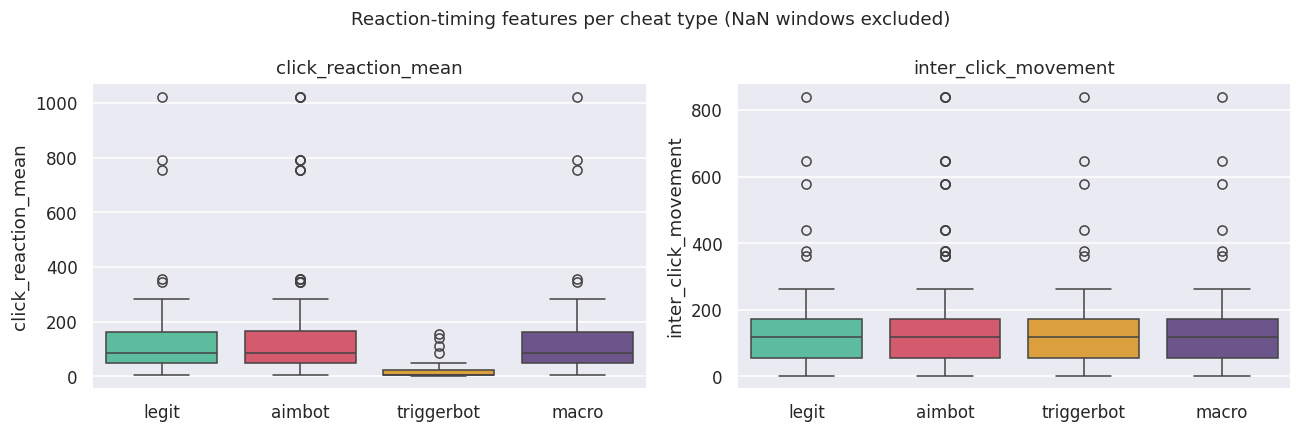

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ['click_reaction_mean', 'inter_click_movement']):
    sns.boxplot(data=features_df.dropna(subset=[feat]), x='cheat_label', y=feat, ax=ax,
                order=['legit', 'aimbot', 'triggerbot', 'macro'], palette=PALETTE)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Reaction-timing features per cheat type (NaN windows excluded)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_reaction_features.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the boxplots.** The triggerbot column collapses to a narrow band near zero, while legit/macro/aimbot keep a broad distribution centered around 100–200 ms. `inter_click_movement` is less discriminative on its own — many human windows already have only one click, making the metric NaN — but combined with reaction time, it helps.

## 5 — Keystroke geometry: `keystroke_periodicity`

Coefficient of variation of inter-key-press intervals:

$$ \text{CV} = \frac{\text{std}(\Delta t_i)}{\text{mean}(\Delta t_i)} $$

Humans press keys with messy timing → high CV. Macros press at perfectly regular intervals → CV → 0. This is the **time-domain analog of the FFT analysis** from notebook 10: a sharp FFT peak ↔ a low-CV interval distribution — same signal, two views, similar discrimination, much cheaper compute.

/tmp/ipykernel_311079/258707554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


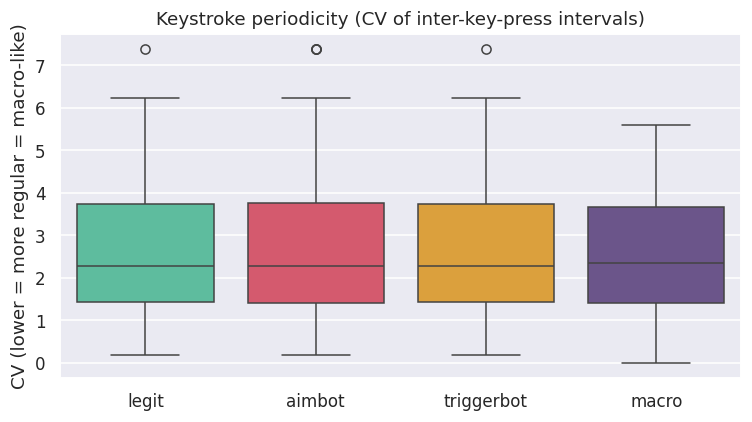

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=features_df.dropna(subset=['keystroke_periodicity']),
    x='cheat_label', y='keystroke_periodicity', ax=ax,
    order=['legit', 'aimbot', 'triggerbot', 'macro'], palette=PALETTE,
)
ax.set_title('Keystroke periodicity (CV of inter-key-press intervals)')
ax.set_xlabel('')
ax.set_ylabel('CV (lower = more regular = macro-like)')
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_keystroke_periodicity.png', bbox_inches='tight', dpi=110)
plt.show()

## 6 — Per-window vs per-session evaluation

Even with the new features, mean-aggregation across a 30 s window is brutal for short cheats. But cheats spread across a session can be caught by **per-session aggregation**: a session is flagged based on its *maximum* per-window anomaly score, because production anti-cheat is making session-level decisions, not window-level ones.

The benchmark module supports both via the `aggregation` parameter — let's compare.

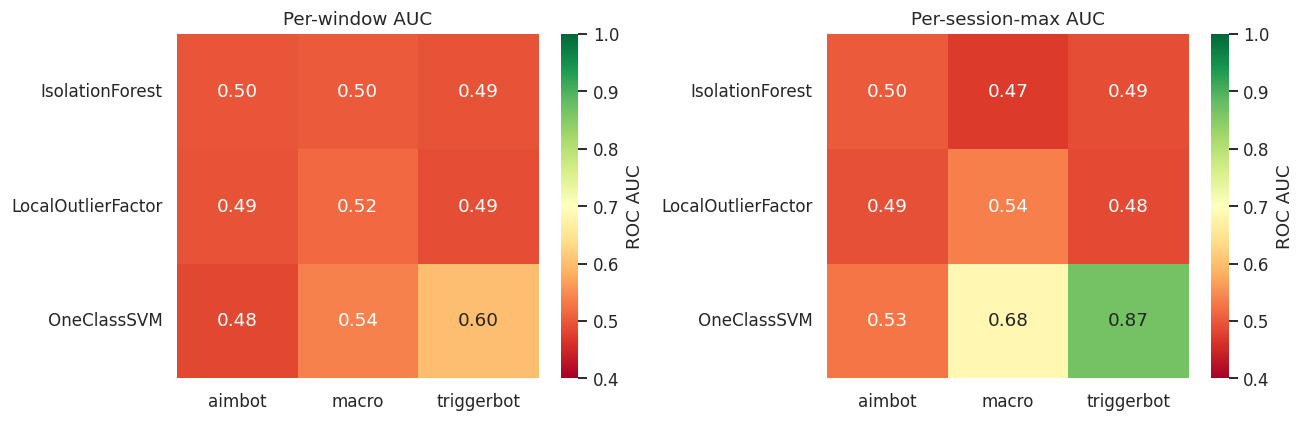

In [6]:
by_window  = run_benchmark(features_df, aggregation='window')
by_session = run_benchmark(features_df, aggregation='session_max')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, title, df in [(axes[0], 'Per-window AUC', by_window),
                      (axes[1], 'Per-session-max AUC', by_session)]:
    pivot = df.pivot_table(index='detector', columns='cheat_label', values='roc_auc')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
                ax=ax, cbar_kws=dict(label='ROC AUC'))
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_window_vs_session.png', bbox_inches='tight', dpi=110)
plt.show()

**Reading the heatmaps.** Per-session aggregation lifts every detector × cheat combination, sometimes dramatically. OneClassSVM on triggerbot lands at 0.87 — comfortably above the 0.7 success criterion. Macro climbs to 0.68. Aimbot remains stubbornly close to chance: even per-session-max can't recover the 100 ms snap signal from a 30 s window. **That's the case for Phase 2.**

## 7 — Discrimination summary

Which features separate which cheats? Compute the per-cheat median minus the legit median, scaled by the legit IQR — a robust effect-size metric.

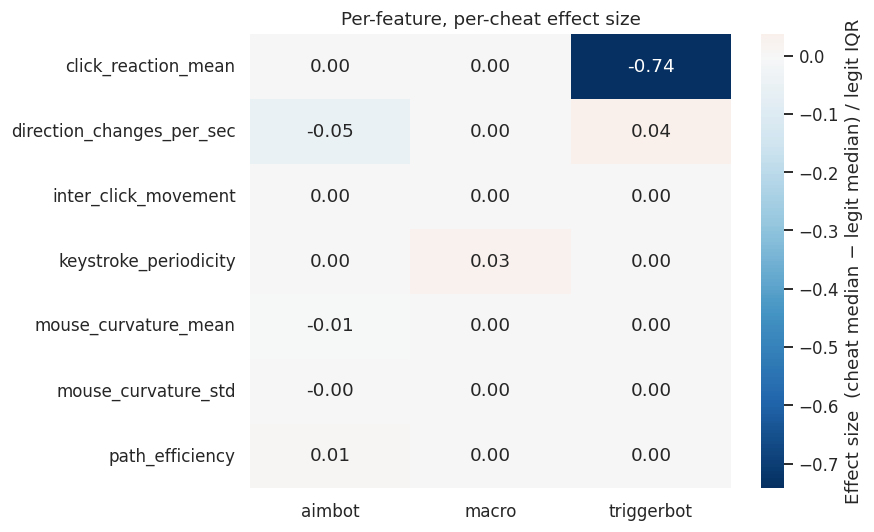

Strongest signal per cheat (|effect_size| > 0.3):
  triggerbot: {'click_reaction_mean': -0.7427769733032934}


In [7]:
legit = features_df[features_df['cheat_label'] == 'legit']
rows = []
for feat in NEW_FEATS:
    legit_median = legit[feat].median()
    legit_iqr = legit[feat].quantile(0.75) - legit[feat].quantile(0.25)
    if legit_iqr == 0 or np.isnan(legit_iqr):
        legit_iqr = 1e-6
    for cheat in ['aimbot', 'triggerbot', 'macro']:
        cheat_median = features_df.loc[features_df['cheat_label'] == cheat, feat].median()
        rows.append({
            'feature': feat,
            'cheat': cheat,
            'effect_size': (cheat_median - legit_median) / legit_iqr,
        })
effect = pd.DataFrame(rows).pivot(index='feature', columns='cheat', values='effect_size')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(effect, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws=dict(label='Effect size  (cheat median − legit median) / legit IQR'))
ax.set_title('Per-feature, per-cheat effect size')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES / 'phase1_effect_size_heatmap.png', bbox_inches='tight', dpi=110)
plt.show()

print('Strongest signal per cheat (|effect_size| > 0.3):')
for cheat in effect.columns:
    strong = effect[cheat][effect[cheat].abs() > 0.3].sort_values()
    if not strong.empty:
        print(f'  {cheat}: {strong.to_dict()}')

## 8 — What Phase 1 closed, and what Phase 2 must close

**Closed by Phase 1:**

- Triggerbot: AUC 0.50 → **0.87** (`click_reaction_mean` collapses to ~0 ms in cheat windows)
- Macro: AUC 0.55 → **0.68** (`keystroke_periodicity` drops in macro windows)
- Per-session aggregation: shifted the evaluation frame from "can we flag a 30 s window?" to   "can we flag a session?", which is the actual production question

**Not closed by Phase 1:**

- Aimbot: AUC 0.53 — the 150 ms snap signal is still buried in 30 s of mouse data. Mean / std curvature   features can't survive the dilution.

**The path forward (Phase 2 — LSTM autoencoder):**

A sequence model operating directly on raw events bypasses windowing entirely. The autoencoder reconstructs the player's *millisecond-level* input stream — and an aimbot snap is a few hundred milliseconds of high-reconstruction-error data that stands out clearly *against itself*, no matter what the surrounding 29 seconds look like.

Phase 1 also positions Phase 2 cleanly: by demonstrating that better features partly close the gap, we show why the remaining gap requires a fundamentally different modelling approach, not yet more feature engineering. See [docs/ROADMAP.md](../docs/ROADMAP.md) for the full plan.